# KND_04 - Step 6: Train and compare four models

## What changes at this step?

We now train prediction models. Each model learns from **6,096 training admissions** and is compared on **1,163 validation admissions**. The target is still **1 = more than 30 days**, **0 = 30 days or less**.

Our four algorithms are Logistic Regression, Decision Tree, Random Forest and Gradient Boosting. We also include a simple baseline, which does not count as one of the four required algorithms.

This is an **initial model comparison**, not final model selection. We do not tune settings, choose a new alert threshold or evaluate the test set here.

## Two files to upload

1. This notebook.
2. **KND_04_Step6_Input_Files.zip**, the matching input bundle.

The first code cell automatically extracts the ZIP if the input folder is absent. The bundle contains training/validation data and our Step 5 helper code. **It contains no test records or test labels.** You do not need to rerun earlier notebooks to use this bundle.

Alternatively, keep an extracted **step6_inputs** folder beside the notebook. In Colab, upload the ZIP to the Files panel, then run the cells in order. Keep its filename unchanged.

Libraries: pandas, numpy, scikit-learn, scipy, joblib and matplotlib. If an import fails, run `%pip install pandas numpy scikit-learn scipy joblib matplotlib` in a separate cell and restart the kernel if prompted. The bundle includes the exact versions used for the checked run. This notebook fits new pipelines, so it does not load an older-version fitted model.

**Source:** [County of Sonoma, Animal Shelter Intake and Outcome](https://data.sonomacounty.ca.gov/Government/Animal-Shelter-Intake-and-Outcome/924a-vesw), California, USA. We use the same approved extract and splits from Steps 2-5.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import hashlib
import importlib
import json
import shutil
import sys
import time
import warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy
import joblib
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (average_precision_score, roc_auc_score, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score, brier_score_loss,
    confusion_matrix, precision_recall_curve)
from threadpoolctl import threadpool_limits

needed = {"train_inputs.csv", "validation_inputs.csv", "train_labels_and_audit.csv",
          "validation_labels_and_audit.csv", "shelter_preprocessing.py",
          "requirements_step6.txt", "README.txt", "input_manifest.json"}
candidates = [Path("step6_inputs"), Path("outputs/step6_inputs"), Path("/content/step6_inputs")]
INPUT_DIR = next((p.resolve() for p in candidates if all((p / name).exists() for name in needed)), None)
if INPUT_DIR is None:
    zip_name = "KND_04_Step6_Input_Files.zip"
    zip_candidates = [Path(zip_name), Path("outputs") / zip_name, Path("/content") / zip_name]
    zip_path = next((p.resolve() for p in zip_candidates if p.exists()), None)
    if zip_path is None:
        raise FileNotFoundError("Upload KND_04_Step6_Input_Files.zip beside this notebook, then rerun this cell.")
    with ZipFile(zip_path) as archive:
        expected_paths = {"step6_inputs/" + name for name in needed}
        if set(archive.namelist()) != expected_paths:
            raise ValueError("Unexpected ZIP contents. Use the complete matching Notebook 6 input bundle.")
        archive.extractall(zip_path.parent)
    INPUT_DIR = zip_path.parent / "step6_inputs"

manifest = json.loads((INPUT_DIR / "input_manifest.json").read_text(encoding="utf-8"))
assert manifest["test_data_included"] is False
assert set(manifest["files_sha256"]) == needed - {"input_manifest.json"}
for name, expected in manifest["files_sha256"].items():
    actual = hashlib.sha256((INPUT_DIR / name).read_bytes()).hexdigest()
    assert actual == expected, f"{name} does not match this bundle. Replace the whole input bundle; do not skip the check."

RESULTS_DIR = INPUT_DIR.parent / "step6_results"
MODELS_DIR = RESULTS_DIR / "fitted_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(INPUT_DIR))
importlib.invalidate_caches()
if "shelter_preprocessing" in sys.modules:
    del sys.modules["shelter_preprocessing"]
import shelter_preprocessing as prep
assert prep.RAW_INPUT_FIELDS == manifest["raw_input_fields"]
print("Matching input bundle found:", INPUT_DIR)
print("Results will save in:", RESULTS_DIR)
print("Test data is not included or loaded.")

Matching input bundle found: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step6_inputs
Results will save in: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step6_results
Test data is not included or loaded.


## 1. Check the training and validation records

We load raw selected inputs and keep the answers and audit details in separate files. Row order is fixed by the matching bundle.

Before learning, we check that the training labels could have been known before validation began, and that no animal appears in both groups. These checks retain the time-based design from Notebook 3.

In [2]:
X_train = pd.read_csv(INPUT_DIR / "train_inputs.csv")
X_validation = pd.read_csv(INPUT_DIR / "validation_inputs.csv")
train_audit = pd.read_csv(INPUT_DIR / "train_labels_and_audit.csv", dtype={"id": "string"})
validation_audit = pd.read_csv(INPUT_DIR / "validation_labels_and_audit.csv", dtype={"id": "string"})
y_train = train_audit["long_stay_30"].to_numpy(dtype=int)
y_validation = validation_audit["long_stay_30"].to_numpy(dtype=int)

assert len(X_train) == len(y_train) == manifest["expected_training_rows"] == 6096
assert len(X_validation) == len(y_validation) == manifest["expected_validation_rows"] == 1163
assert list(X_train.columns) == list(X_validation.columns) == prep.RAW_INPUT_FIELDS
assert set(np.unique(y_train)) == set(np.unique(y_validation)) == {0, 1}
assert set(train_audit["id"]).isdisjoint(validation_audit["id"])
assert set(train_audit["source_row_number"]).isdisjoint(validation_audit["source_row_number"])
for inputs, audit in [(X_train, train_audit), (X_validation, validation_audit)]:
    assert audit["source_row_number"].is_unique and audit["id"].notna().all()
    assert pd.to_datetime(inputs["intake_date"]).equals(pd.to_datetime(audit["intake_date"]))
assert (pd.to_datetime(X_train["intake_date"]) < pd.Timestamp(manifest["training_end_exclusive"])).all()
assert (pd.to_datetime(train_audit["label_known_date"]) < pd.Timestamp(manifest["validation_start"])).all()
assert (pd.to_datetime(X_validation["intake_date"]) >= pd.Timestamp(manifest["validation_start"])).all()
assert (pd.to_datetime(X_validation["intake_date"]) < pd.Timestamp(manifest["validation_end_exclusive"])).all()
assert (pd.to_datetime(validation_audit["label_known_date"]) < pd.Timestamp(manifest["test_start"])).all()

print("Training records:", len(X_train))
print("Validation records:", len(X_validation))
print("Validation long-stay share:", round(100 * y_validation.mean(), 2), "%")
print("Row, date and animal-overlap checks passed.")

Training records: 6096
Validation records: 1163
Validation long-stay share: 21.07 %
Row, date and animal-overlap checks passed.


## 2. Decide how we will compare models

We set these rules **before seeing model scores**:

- **Primary ranking: average precision (AP).** This summarises how well the model finds long stays across different alert thresholds. Higher is better. It is not ordinary accuracy or precision at one cutoff.
- **Precision:** of the animals we flag for a long stay, how many really stay longer?
- **Recall:** of all actual long stays, how many do we catch?
- **F1:** combines precision and recall into one score.
- **Balanced accuracy:** averages how well we recognise short stays and long stays.
- **Accuracy:** the overall fraction correct; useful, but not sufficient by itself.
- **ROC-AUC:** another ranking measure; higher is better.
- **Brier score:** measures error in probability estimates; lower is better. This is a diagnostic, not proof that the scores are calibrated.

For class predictions, every model uses **score >= 0.50 to flag a long stay**. This is a starting rule, not an optimised or shelter-approved alert threshold. We will discuss the trade-off between missed cases and unnecessary alerts later.

**Made-up example:** of 10 actual long stays, we catch 6. Recall is 6/10 = 60%. If we flagged 8 animals in total, precision is 6/8 = 75%. These numbers are only an explanation, not our results.

Our positive class is always **long stay (1)**. The baseline assigns every animal the training long-stay rate. Since that rate is below 0.50, it predicts short stay for every admission. A useful model should improve meaningfully on this simple rule.

In [3]:
SEED = 42
ALERT_THRESHOLD = 0.50
PRIMARY_METRIC = "validation_average_precision"
np.random.seed(SEED)

def evaluate(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    assert len(scores) == len(y_true) and np.isfinite(scores).all()
    assert ((scores >= 0) & (scores <= 1)).all()
    prediction = (scores >= ALERT_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "average_precision": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "brier_score": brier_score_loss(y_true, scores),
        "true_short": int(tn), "false_alerts": int(fp),
        "missed_long_stays": int(fn), "caught_long_stays": int(tp),
    }

print("Primary ranking:", PRIMARY_METRIC)
print("Initial alert threshold:", ALERT_THRESHOLD)
print("No threshold search or test evaluation will run in this notebook.")

Primary ranking: validation_average_precision
Initial alert threshold: 0.5
No threshold search or test evaluation will run in this notebook.


## 3. Define the four models

**Logistic Regression:** learns how input values combine into a long-stay score. Despite its name, we use it for classification.

**Decision Tree:** asks a sequence of questions and follows branches to a prediction. We limit depth and require at least 10 training records in a leaf to avoid extremely tiny rules.

**Random Forest:** combines many trees, each learning from a random sample of training records and considering subsets of features. Combining trees can reduce reliance on one unstable tree.

**Gradient Boosting:** adds small trees in sequence, with later trees helping correct earlier errors.

The settings below are fixed starting choices. We are not claiming they are optimal or equally complex. All four models use the same records and preprocessing rules, and **no class weighting or resampling in this first comparison**. We will compare weighting and tuned settings later.

We disable Gradient Boosting's optional early-stopping split. It would otherwise create an internal random holdout that does not follow our chosen chronological split. The shared validation set remains outside fitting.

In [4]:
model_specs = {
    "baseline": ("Baseline (training rate)", DummyClassifier(strategy="prior")),
    "logistic_regression": ("Logistic Regression", LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=2000, random_state=SEED)),
    "decision_tree": ("Decision Tree", DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=10, random_state=SEED)),
    "random_forest": ("Random Forest", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, random_state=SEED, n_jobs=1)),
    "gradient_boosting": ("Gradient Boosting", GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        min_samples_leaf=5, n_iter_no_change=None, random_state=SEED)),
}
experiment_settings = {
    "seed": SEED, "alert_threshold": ALERT_THRESHOLD,
    "primary_metric": PRIMARY_METRIC,
    "preprocessing_rare_min_count": 10,
    "models": {key: {"name": name, "parameters": model.get_params()}
               for key, (name, model) in model_specs.items()},
    "training_only": True, "sample_weighting": False, "test_evaluation": False,
}
(RESULTS_DIR / "experiment_settings.json").write_text(json.dumps(experiment_settings, indent=2), encoding="utf-8")
for key, (name, model) in model_specs.items():
    print(name, "->", type(model).__name__)
print("Settings saved before training.")

Baseline (training rate) -> DummyClassifier
Logistic Regression -> LogisticRegression
Decision Tree -> DecisionTreeClassifier
Random Forest -> RandomForestClassifier
Gradient Boosting -> GradientBoostingClassifier
Settings saved before training.


## 4. Train on training data, compare on validation data

Each model gets a **fresh preprocessing pipeline**. Its age replacements, category groups and scaling are fitted using training inputs only. The complete pipeline then prepares validation inputs and predicts their scores.

Training scores show how well a model fits familiar records. Validation scores are the comparison that matters here. A large training-to-validation drop can be a warning about overfitting or changes between periods; it does not identify the cause by itself.

This cell can take a few minutes on a laptop. The seed and settings are fixed, but timing and small numerical differences can vary across computers or library versions.

In [5]:
models, validation_scores, rows, run_warnings = {}, {}, [], {}
run_started = datetime.now(timezone.utc).isoformat()
for key, (name, estimator) in model_specs.items():
    print("Training", name, "...", flush=True)
    pipeline = Pipeline([("preprocess", prep.make_preprocessor(rare_min_count=10)),
                         ("model", clone(estimator))])
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        with threadpool_limits(limits=1):
            pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started
    run_warnings[key] = [{"category": item.category.__name__, "message": str(item.message)} for item in caught]
    if any(issubclass(item.category, ConvergenceWarning) for item in caught):
        raise RuntimeError(name + " did not converge. Review the recorded warning before using its result.")
    for item in run_warnings[key]:
        print("Warning:", item["category"], item["message"])

    positive_index = int(np.flatnonzero(pipeline.named_steps["model"].classes_ == 1)[0])
    learned_hash = joblib.hash(pipeline.named_steps["preprocess"])
    with threadpool_limits(limits=1):
        train_scores = pipeline.predict_proba(X_train)[:, positive_index]
        scores = pipeline.predict_proba(X_validation)[:, positive_index]
    assert joblib.hash(pipeline.named_steps["preprocess"]) == learned_hash
    assert pipeline.named_steps["preprocess"].named_steps["features"].fit_rows_ == len(X_train)
    assert len(pipeline.named_steps["preprocess"].get_feature_names_out()) == manifest["expected_encoded_features"]

    train_metrics = evaluate(y_train, train_scores)
    validation_metrics = evaluate(y_validation, scores)
    row = {"model_key": key, "model": name, "fit_seconds": fit_seconds}
    row.update({"training_" + metric: value for metric, value in train_metrics.items()})
    row.update({"validation_" + metric: value for metric, value in validation_metrics.items()})
    rows.append(row)
    models[key] = pipeline
    validation_scores[key] = scores
    joblib.dump(pipeline, MODELS_DIR / f"{key}.joblib", compress=3)
    print("Validation AP:", round(validation_metrics["average_precision"], 4),
          "Recall:", round(validation_metrics["recall"], 4),
          "F1:", round(validation_metrics["f1"], 4))

comparison = pd.DataFrame(rows).sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)
comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print("Finished four ML models and one baseline. No test evaluation performed.")

Training Baseline (training rate) ...
Validation AP: 0.2107 Recall: 0.0 F1: 0.0
Training Logistic Regression ...
Validation AP: 0.3496 Recall: 0.4653 F1: 0.4057
Training Decision Tree ...
Validation AP: 0.2894 Recall: 0.5224 F1: 0.3963
Training Random Forest ...
Validation AP: 0.3585 Recall: 0.4286 F1: 0.3818
Training Gradient Boosting ...
Validation AP: 0.3672 Recall: 0.4735 F1: 0.4085
Finished four ML models and one baseline. No test evaluation performed.


## 5. Read the results together

The table is sorted by validation AP. Scores such as 0.70 mean 70% for accuracy/precision/recall, but AP is a ranking summary, not a percentage of correct predictions. Every class metric below uses the same 0.50 threshold.

Check more than the top row:

- Does the model outperform the baseline?
- Does it catch enough long stays for the proposed use?
- How many unnecessary alerts does it produce?
- Is there a large training-validation gap?

The top validation-AP model is a **candidate for further work**, not automatically the final model. Higher recall can come with more false alerts. Probability scores are not yet calibrated or ready to be presented as reliable chances to shelter staff.

In [6]:
display_columns = ["model", "validation_average_precision", "validation_precision",
                   "validation_recall", "validation_f1", "validation_balanced_accuracy",
                   "validation_accuracy", "validation_brier_score"]
print(comparison[display_columns].round(4).to_string(index=False))

ml_results = comparison.loc[comparison["model_key"].ne("baseline")].copy()
candidate = ml_results.iloc[0]
baseline_ap = float(comparison.loc[comparison["model_key"].eq("baseline"), PRIMARY_METRIC].iloc[0])
print("\nHighest validation AP among the four ML models:", candidate["model"])
print("Validation AP:", round(float(candidate[PRIMARY_METRIC]), 4))
print("Baseline AP:", round(baseline_ap, 4))
print("This is a starting comparison, not final selection or a test score.")
print("\nRead the mistakes, not only the ranking:")
print(candidate["model"], "caught", int(candidate["validation_caught_long_stays"]),
      "of", int(y_validation.sum()), "actual long stays;")
print("missed", int(candidate["validation_missed_long_stays"]),
      "and produced", int(candidate["validation_false_alerts"]), "false alerts at 0.50.")
baseline_result = comparison.loc[comparison["model_key"].eq("baseline")].iloc[0]
print("Candidate accuracy:", round(float(candidate["validation_accuracy"]), 4),
      "; always-short baseline accuracy:", round(float(baseline_result["validation_accuracy"]), 4))
print("The always-short baseline catches zero long stays.")
if candidate["validation_brier_score"] >= baseline_result["validation_brier_score"]:
    print("The leading AP model has not improved Brier probability error over the baseline.")
print("Long-stay share: training", round(100 * y_train.mean(), 2),
      "%, validation", round(100 * y_validation.mean(), 2), "%.")
print("AP can change with class balance, so a training-validation gap is not proof of overfitting alone.")
print("Next: investigate generalisation, weighting, threshold trade-offs and calibration; do not claim readiness for use.")

                   model  validation_average_precision  validation_precision  validation_recall  validation_f1  validation_balanced_accuracy  validation_accuracy  validation_brier_score
       Gradient Boosting                        0.3672                0.3591             0.4735         0.4085                        0.6240               0.7111                  0.1778
           Random Forest                        0.3585                0.3443             0.4286         0.3818                        0.6054               0.7077                  0.1780
     Logistic Regression                        0.3496                0.3596             0.4653         0.4057                        0.6221               0.7128                  0.1919
           Decision Tree                        0.2894                0.3192             0.5224         0.3963                        0.6125               0.6647                  0.1997
Baseline (training rate)                        0.2107                

## 6. Charts for the report

**AP chart:** compares ranking performance on validation data.

**Precision-recall curves:** show the trade-off as the alert threshold changes. The horizontal reference is the validation long-stay share, equal to AP for a constant-score baseline. We are not selecting a threshold from this plot yet.

**Confusion matrices:** count correct decisions and mistakes at 0.50. Rows are actual labels and columns are predictions. The upper-right cell is a false alert; the lower-left cell is a missed long stay.

**Training versus validation AP:** helps reveal a gap between familiar and later records. These plots describe one validation period and are not guarantees of future performance.

Saved four charts.


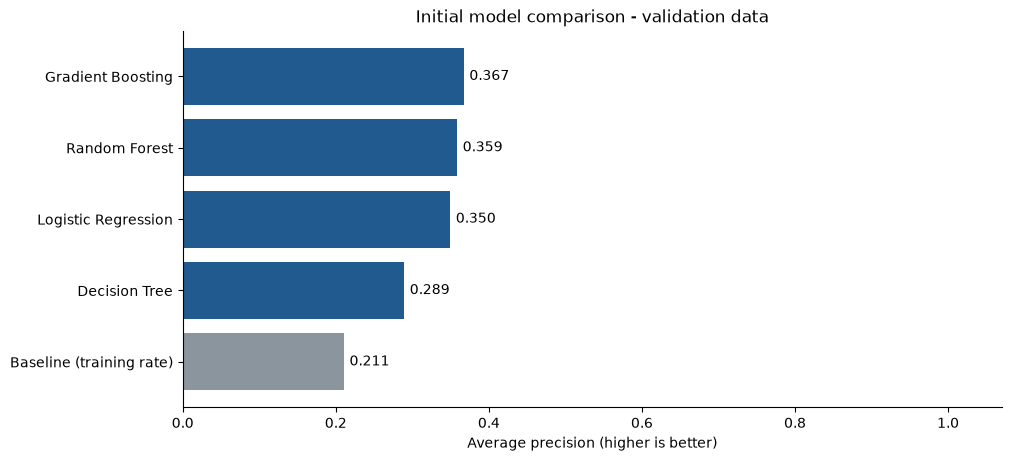

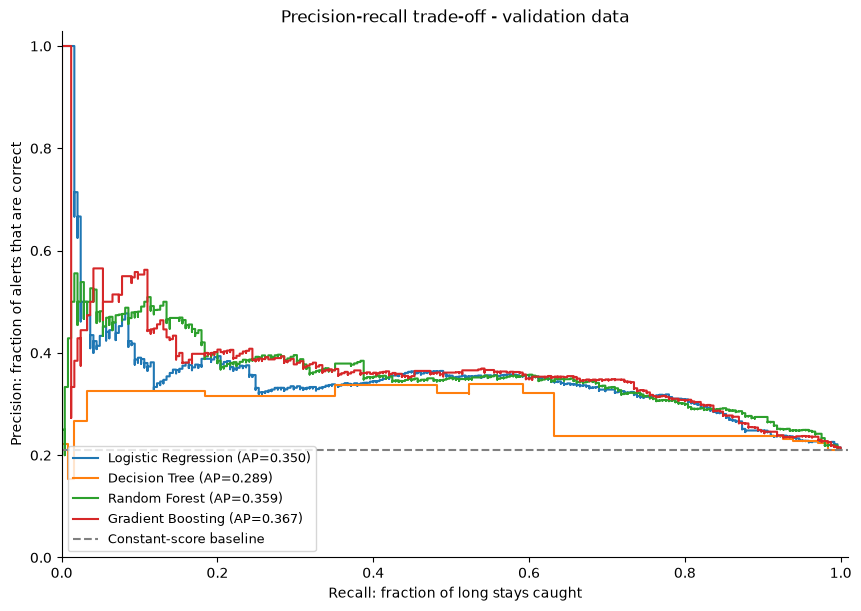

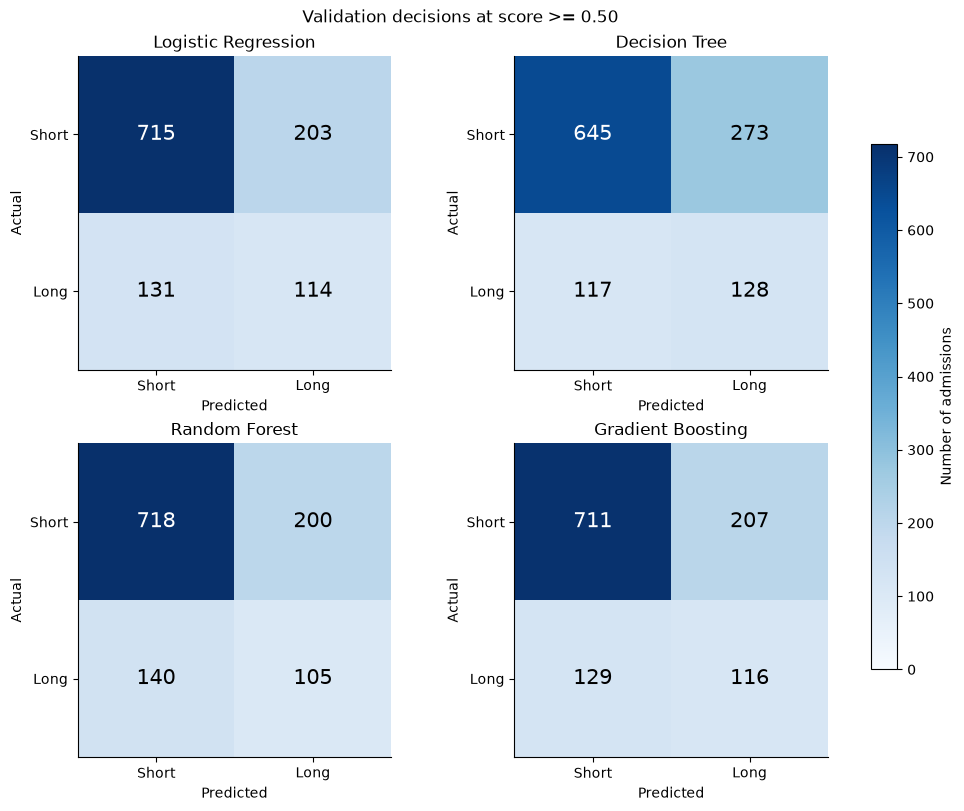

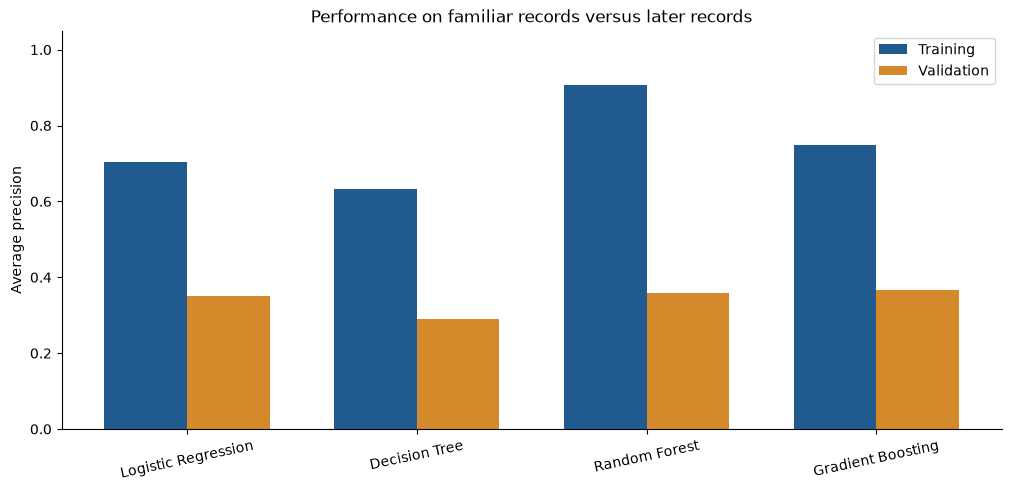

In [7]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
def save_chart(fig, filename):
    fig.savefig(RESULTS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

shown = comparison.sort_values(PRIMARY_METRIC)
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
bars = ax.barh(shown["model"], shown[PRIMARY_METRIC],
               color=["#8b959d" if k == "baseline" else "#215a8e" for k in shown["model_key"]])
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set(xlim=(0, 1.07), xlabel="Average precision (higher is better)", title="Initial model comparison - validation data")
save_chart(fig, "01_validation_average_precision.png")

fig, ax = plt.subplots(figsize=(8.5, 6), layout="constrained")
for key, (name, _) in model_specs.items():
    if key == "baseline":
        continue
    precision, recall, _ = precision_recall_curve(y_validation, validation_scores[key])
    ap = float(comparison.loc[comparison["model_key"].eq(key), PRIMARY_METRIC].iloc[0])
    ax.step(recall, precision, where="post", label=f"{name} (AP={ap:.3f})")
ax.axhline(y_validation.mean(), color="gray", linestyle="--", label="Constant-score baseline")
ax.set(xlim=(0, 1.01), ylim=(0, 1.03), xlabel="Recall: fraction of long stays caught",
       ylabel="Precision: fraction of alerts that are correct", title="Precision-recall trade-off - validation data")
ax.legend(loc="lower left", fontsize=9)
save_chart(fig, "02_validation_precision_recall.png")

ml_keys = [key for key in model_specs if key != "baseline"]
matrices = {key: confusion_matrix(y_validation, (validation_scores[key] >= ALERT_THRESHOLD).astype(int), labels=[0, 1])
            for key in ml_keys}
vmax = max(int(matrix.max()) for matrix in matrices.values())
fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout="constrained")
for ax, key in zip(axes.flat, ml_keys):
    matrix = matrices[key]
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=15,
                    color="white" if matrix[i, j] > vmax / 2 else "black")
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Short", "Long"], yticklabels=["Short", "Long"],
           xlabel="Predicted", ylabel="Actual", title=model_specs[key][0])
fig.colorbar(image, ax=axes.ravel().tolist(), label="Number of admissions", shrink=0.75)
fig.suptitle("Validation decisions at score >= 0.50")
save_chart(fig, "03_validation_confusion_matrices.png")

ordered = comparison.loc[comparison["model_key"].ne("baseline")].set_index("model_key").loc[ml_keys]
fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
x = np.arange(len(ordered))
ax.bar(x - 0.18, ordered["training_average_precision"], width=0.36, label="Training", color="#215a8e")
ax.bar(x + 0.18, ordered[PRIMARY_METRIC], width=0.36, label="Validation", color="#d48a2b")
ax.set(xticks=x, xticklabels=ordered["model"], ylim=(0, 1.05), ylabel="Average precision",
       title="Performance on familiar records versus later records")
ax.tick_params(axis="x", labelrotation=12)
ax.legend()
save_chart(fig, "04_training_validation_gap.png")
print("Saved four charts.")

## 7. Save the evidence and model pipelines

The results folder contains:

- `model_comparison.csv`: full training/validation metrics and fit times.
- `validation_predictions.csv`: scores, predicted labels and actual labels for checking errors.
- `validation_confusion_counts.csv`: missed cases, false alerts and correct decisions.
- `fitted_models`: four ML pipelines plus the baseline, each including preprocessing.
- `shelter_preprocessing.py`: helper code needed to reload the pipelines.
- Four PNG charts, experiment settings, run notes, exact dependency versions and a README.

These are initial fitted models. They are not final deployment artifacts. If your group changes settings, record the experiment and compare on validation data rather than inspecting the test set.

Rerunning this notebook replaces its generated results. Copy the results folder with a clear experiment name before deliberately trying a different setup.

In [8]:
prediction_frames = []
for key, scores in validation_scores.items():
    frame = validation_audit[["source_row_number", "id", "intake_date"]].copy()
    frame["model_key"] = key
    frame["actual_long_stay"] = y_validation
    frame["long_stay_score"] = scores
    frame["predicted_long_stay"] = (scores >= ALERT_THRESHOLD).astype(int)
    prediction_frames.append(frame)
predictions = pd.concat(prediction_frames, ignore_index=True)
predictions.to_csv(RESULTS_DIR / "validation_predictions.csv", index=False)
confusion_columns = ["model", "validation_true_short", "validation_false_alerts",
                     "validation_missed_long_stays", "validation_caught_long_stays"]
comparison[confusion_columns].to_csv(RESULTS_DIR / "validation_confusion_counts.csv", index=False)
shutil.copyfile(INPUT_DIR / "shelter_preprocessing.py", RESULTS_DIR / "shelter_preprocessing.py")

versions = {"pandas": pd.__version__, "numpy": np.__version__, "scikit-learn": sklearn.__version__,
            "scipy": scipy.__version__, "joblib": joblib.__version__, "matplotlib": __import__("matplotlib").__version__}
(RESULTS_DIR / "requirements_modeling.txt").write_text(
    "\n".join(f"{name}=={version}" for name, version in versions.items()) + "\n", encoding="utf-8")
notes = {
    "run_started_utc": run_started, "run_finished_utc": datetime.now(timezone.utc).isoformat(),
    "training_rows": len(X_train), "validation_rows": len(X_validation),
    "validation_long_stays": int(y_validation.sum()), "validation_short_stays": int((y_validation == 0).sum()),
    "primary_metric": PRIMARY_METRIC, "alert_threshold": ALERT_THRESHOLD,
    "highest_validation_ap_ml_model": str(candidate["model"]),
    "highest_validation_ap": float(candidate[PRIMARY_METRIC]), "baseline_validation_ap": baseline_ap,
    "test_data_loaded": False, "test_evaluated": False, "hyperparameters_tuned": False,
    "threshold_tuned": False, "probabilities_calibrated": False, "final_model_selected": False,
    "libraries": versions, "python_version": sys.version.split()[0], "warnings": run_warnings,
    "input_files_sha256": manifest["files_sha256"],
    "model_file_sha256": {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(MODELS_DIR.glob("*.joblib"))},
    "limitations": [
        "One chronological validation period; these are model-selection results, not an unbiased final test.",
        "Scores are not yet calibrated and the 0.50 threshold is an initial choice.",
        "Repeated visits can remain within a split; metrics count admission events.",
        "Unknown-outcome, historical-attribute and country-specific limitations from earlier steps remain.",
        "These associations and predictions do not prove causes or improved shelter outcomes."
    ],
    "next_step": "Tune candidate models and compare weighting using training/validation only; preserve final test data.",
    "documentation": [
        "https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html",
        "https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html",
        "https://scikit-learn.org/stable/common_pitfalls.html"
    ]
}
(RESULTS_DIR / "model_comparison_notes.json").write_text(json.dumps(notes, indent=2), encoding="utf-8")
(RESULTS_DIR / "README.txt").write_text("""KND_04 Step 6 - Initial model comparison

Validation results only. Four ML algorithms and one baseline have been fitted.
No test data, test scores, hyperparameter search or threshold search were used.
The highest validation-AP model is a candidate, not the final selected model.

Keep this folder together with its fitted_models subfolder and helper module.
Use requirements_modeling.txt for the tested dependency versions.
To reload one complete pipeline:
    from pathlib import Path
    import sys, joblib
    folder = Path('step6_results').resolve()
    sys.path.insert(0, str(folder))
    pipeline = joblib.load(folder / 'fitted_models/logistic_regression.joblib')
    scores = pipeline.predict_proba(new_arrival_dataframe)[:, 1]

Provide the same ten raw arrival fields as Step 5. The pipeline includes age
replacement, category preparation, encoding, scaling and the classifier.
These uncalibrated scores are not ready-made clinical/welfare decisions.

For tuning, create a fresh full pipeline per training fold and keep time/group
checks. Do not randomly cross-validate globally preprocessed arrays. Keep the
final test split reserved until settings and model choices are fixed.
""", encoding="utf-8")
print("Saved model pipelines, metrics, predictions, charts and run notes.")

Saved model pipelines, metrics, predictions, charts and run notes.


## 8. Check the saved results

We reload each saved pipeline and compare its validation predictions with the recorded scores. We also recheck that every confusion matrix accounts for all validation records and the inputs stayed unchanged.

No score is hard-coded as an expected model result. Counts and consistency checks should pass; small score differences across software versions must be reported honestly.

In [9]:
assert set(models) == set(model_specs) and len(models) == 5
assert len(comparison) == 5 and len(predictions) == 5 * len(X_validation)
for key, pipeline in models.items():
    restored = joblib.load(MODELS_DIR / f"{key}.joblib")
    positive_index = int(np.flatnonzero(restored.named_steps["model"].classes_ == 1)[0])
    with threadpool_limits(limits=1):
        restored_scores = restored.predict_proba(X_validation)[:, positive_index]
    np.testing.assert_allclose(restored_scores, validation_scores[key], rtol=1e-10, atol=1e-12)
    row = comparison.loc[comparison["model_key"].eq(key)].iloc[0]
    total = sum(int(row["validation_" + field]) for field in ["true_short", "false_alerts", "missed_long_stays", "caught_long_stays"])
    assert total == len(X_validation)
    assert 0 <= float(row[PRIMARY_METRIC]) <= 1

baseline_row = comparison.loc[comparison["model_key"].eq("baseline")].iloc[0]
assert baseline_row["validation_recall"] == 0
assert np.isclose(baseline_row[PRIMARY_METRIC], y_validation.mean())
for name, fingerprint in manifest["files_sha256"].items():
    assert hashlib.sha256((INPUT_DIR / name).read_bytes()).hexdigest() == fingerprint
print("Saved-pipeline, metric, row-count and input-file checks passed.")
print("Test set remains reserved. Results saved in:", RESULTS_DIR)

Saved-pipeline, metric, row-count and input-file checks passed.
Test set remains reserved. Results saved in: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step6_results


## Group work and simple viva explanations

Assign one algorithm to each member. Each person should explain how it learns, its starting settings, its validation results, one weakness and how it compares with the baseline. Everyone should understand the full train/validation/test workflow.

**Say this:** "We trained four models on the same training data. Each model learned preprocessing only from training inputs. We compared them on later validation records using average precision, precision, recall, F1 and other checks. We also counted missed long stays and false alerts. These are initial validation results; we have not selected the final model or evaluated the test set."

Fill these in using your actual results:

1. The highest validation-AP model was __, with AP __.
2. At 0.50, it caught __ long stays, missed __ and produced __ false alerts.
3. Its training AP was __ compared with validation AP __. A possible explanation to investigate is __.
4. We still need to tune __ and compare __ before final selection.

**Important limits:** this is one US county and one validation period. Labels for assumed ongoing stays and the timing of mutable attributes remain limitations. Predictions do not prove why an animal stays longer or that the system improves outcomes.

## Next: Notebook 7 - Improve the models

We will compare training-only weighting and selected settings, preserve temporal/group-aware validation, consider the alert-threshold trade-off and assess probability calibration. Final test evaluation comes only after the choices are fixed.

References: [average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html), [Gradient Boosting and its optional internal validation split](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html), and [leakage prevention](https://scikit-learn.org/stable/common_pitfalls.html).